# Figures for Paper

In [180]:
import pandas as pd
import numpy as np

import tomllib
import json
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import re
from pathlib import Path

ROOT_DIR = Path("..")

In [181]:
def read_summary(experiments_dir: Path, summary_name: str = "iterations_summary.csv") -> pd.DataFrame:
  csv_path = experiments_dir / summary_name
  df = pd.read_csv(csv_path)

  for col in ["coll_time", "povm_weakness", "n_timesteps"]:
      if not col in df.columns:
          print(f"Adding column {col} to dataframe...")
          df[col] = np.zeros(len(df))
          for i, row in df.iterrows():
              config_path = experiments_dir / row["name"] / "config.toml"
              with open(config_path, "rb") as f:
                  config = tomllib.load(f)
              df.at[i, col] = config[col]

  return df


experiments_dir1 = ROOT_DIR / "experiments/fig1"
df = read_summary(experiments_dir1)

Adding column povm_weakness to dataframe...


In [182]:
def plot_fidelity_variations(
    series,
    experiments_dir,
    x_col="beta",
    y_col="avg_fidelities",
    ax=None,
    plot_infidelity=True,
    labelname="n",
    savepath=None,
    connect_points=True,
    marker_size=6,
    linewidth=1.5,
    alpha=0.9,
    **kwargs
):

    series = list(series)
    title = kwargs.pop("title", None)
    xlabel = kwargs.pop("xlabel", x_col)
    ylabel = kwargs.pop("ylabel", y_col)

    if ax is None:
      fig, ax = plt.subplots(figsize=(8, 6))
      if title is not None:
        ax.set_title(title)
    else:
      fig = ax.figure
      if title is not None:
        ax.text(0.02, 0.02, title, color="gray", transform=ax.transAxes, ha="left", va="bottom", fontsize=12)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Normalize labelname
    if isinstance(labelname, str):
        labelnames = (labelname,)
    elif isinstance(labelname, tuple):
        labelnames = labelname
    else:
        raise TypeError("labelname must be a string or a tuple of strings.")

    n_grouping_vars = len(labelnames)

    if n_grouping_vars > 2:
        raise ValueError(
            "This function supports at most two grouping variables. "
            "Use one variable for colors and one for markers."
        )

    # Normalize group keys
    normalized_series = []

    for key, dataframe in series:
        if not isinstance(key, tuple):
            key = (key,)

        if len(key) != n_grouping_vars:
            raise ValueError(
                f"Group key {key} has length {len(key)}, but labelname has "
                f"length {n_grouping_vars}."
            )

        normalized_series.append((key, dataframe))

    def format_value(value):
        if isinstance(value, float):
            return f"{value:g}"
        return str(value)

    def format_label(name, value):
        return rf"${name}={format_value(value)}$"

    # Available styles
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    markers = [
        "o",  # circle
        "s",  # square
        "^",  # triangle up
        "D",  # diamond
        "v",  # triangle down
        "P",  # plus-filled
        "X",  # x-filled
        "*",  # star
    ]

    if n_grouping_vars == 1:
        color_var_idx = 0
        marker_var_idx = None

        color_values = sorted(set(key[color_var_idx] for key, _ in normalized_series))

        color_map = {
            value: color_cycle[i % len(color_cycle)]
            for i, value in enumerate(color_values)
        }

        marker_map = {}

    else:
        values_0 = sorted(set(key[0] for key, _ in normalized_series))
        values_1 = sorted(set(key[1] for key, _ in normalized_series))

        n_values_0 = len(values_0)
        n_values_1 = len(values_1)

        # Marker goes to the less populated parameter.
        # If tied, use the second parameter as marker by convention.
        if n_values_0 < n_values_1:
            marker_var_idx = 0
            color_var_idx = 1
        else:
            marker_var_idx = 1
            color_var_idx = 0

        color_values = sorted(set(key[color_var_idx] for key, _ in normalized_series))
        marker_values = sorted(set(key[marker_var_idx] for key, _ in normalized_series))

        if len(marker_values) > len(markers):
            raise ValueError(
                f"Too many values for marker variable "
                f"{labelnames[marker_var_idx]}: got {len(marker_values)}, "
                f"but only {len(markers)} markers are defined."
            )

        color_map = {
            value: color_cycle[i % len(color_cycle)]
            for i, value in enumerate(color_values)
        }

        marker_map = {
            value: markers[i]
            for i, value in enumerate(marker_values)
        }

    # Plot data
    for key, dataframe in normalized_series:
        xs = []
        ys = []

        dataframe = dataframe.sort_values(x_col)

        for _, row in dataframe.iterrows():
            x_value = row[x_col]

            results_path = experiments_dir / row["name"] / "data" / "results.json"
            with open(results_path, "r") as f:
                results = json.load(f)

            y_value = results[y_col][-1]

            if plot_infidelity:
                y_value = 1 - y_value

            xs.append(x_value)
            ys.append(y_value)

        color_value = key[color_var_idx]
        color = color_map[color_value]

        if marker_var_idx is None:
            marker = "o"
        else:
            marker_value = key[marker_var_idx]
            marker = marker_map[marker_value]

        label = ", ".join(
            format_label(name, value)
            for name, value in zip(labelnames, key)
        )

        plot_kwargs = dict(
            color=color,
            marker=marker,
            markersize=marker_size,
            alpha=alpha,
            label=label,
        )

        plot_kwargs.update(kwargs)

        if connect_points:
            ax.plot(
                xs,
                ys,
                linestyle="-",
                linewidth=linewidth,
                **plot_kwargs
            )
        else:
            ax.plot(
                xs,
                ys,
                linestyle="",
                **plot_kwargs
            )

    ax.set_yscale("log")
    ax.set_axisbelow(True)
    ax.minorticks_on()
    ax.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.35)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.18)

    # Legends
    if n_grouping_vars == 1:
        handles = [
            Line2D(
                [0], [0],
                color=color_map[value],
                marker="o",
                linestyle="-",
                label=format_label(labelnames[0], value)
            )
            for value in color_values
        ]

        ax.legend(
            handles=handles,
            title=rf"${labelnames[0]}$"
        )

    else:
        color_handles = [
            Line2D(
                [0], [0],
                color=color_map[value],
                marker="o",
                linestyle="-",
                label=format_label(labelnames[color_var_idx], value)
            )
            for value in color_values
        ]

        marker_handles = [
            Line2D(
                [0], [0],
                color="black",
                marker=marker_map[value],
                linestyle="",
                label=format_label(labelnames[marker_var_idx], value)
            )
            for value in marker_values
        ]

        color_legend = ax.legend(
            handles=color_handles,
            title=rf"${labelnames[color_var_idx]}$",
        )

        ax.add_artist(color_legend)

        ax.legend(
            handles=marker_handles,
            title=rf"${labelnames[marker_var_idx]}$",
            loc="upper right",
            bbox_to_anchor=(1.0, 0.65),
        )

    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight")

    return fig, ax

In [183]:
def remove_big_files():
  for i in experiments_dir1.iterdir():
    if i.is_dir() and i.name.startswith("reference_n5"):
      superoperator_file = i / "data" / "superoperators.jld2"
      superoperator_file.unlink(missing_ok=True)
remove_big_files()        

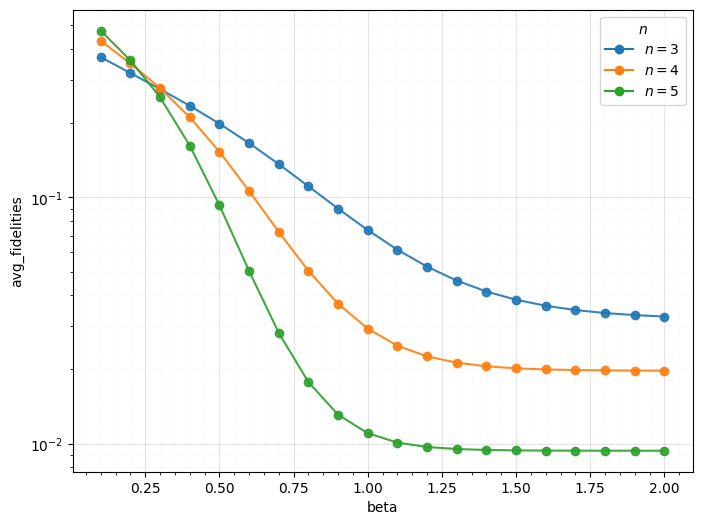

In [184]:
exp_name = "reference_"
exp_variable = "n_qubits"

filtered_df = df[df["name"].str.startswith(exp_name)]
series1a = filtered_df.groupby(exp_variable)

fig1a, ax1a = plot_fidelity_variations(series1a, x_col="beta", y_col="avg_fidelities", plot_infidelity=True, labelname="n", 
                                       experiments_dir=experiments_dir1,
                         savepath=experiments_dir1 / "fig1a.png")

### Fig.1b
Here we show the effect of increasing the time of the first informative collision

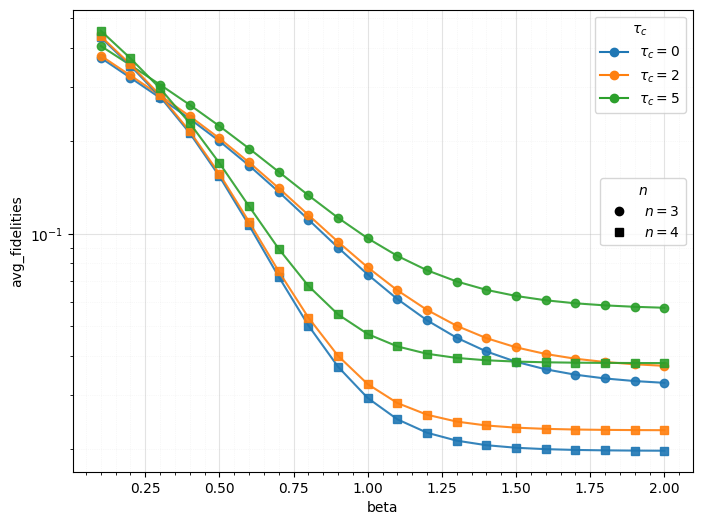

In [185]:
exp_name = "b_"
exp_variable = ["n_qubits", "coll_time"]

filtered_df = df[df["name"].str.startswith(exp_name)]
filtered_df = filtered_df[filtered_df["coll_time"].isin([0.0, 2.0, 5.0])]
series1b = filtered_df.groupby(exp_variable)

fig1b, ax1b = plot_fidelity_variations(series1b, x_col="beta", y_col="avg_fidelities", plot_infidelity=True, labelname=("n", r"\tau_c"), 
                                       experiments_dir=experiments_dir1,
                         savepath=experiments_dir1 / "fig1b.png")

### Fig.1c
Here we show the effect of increasing the weight of the collapse, where in our weak measurements we mix the identity with the POVM as $\Pi_\text{weak}=w I + (1-w) \Pi$

0.019763472009847183


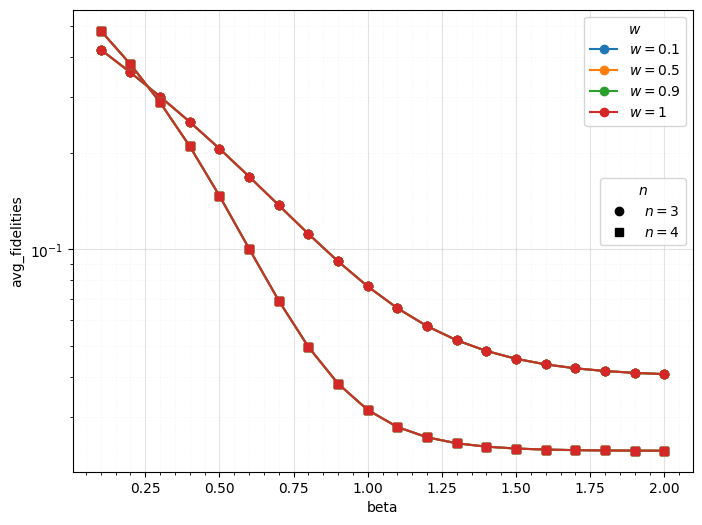

In [186]:
exp_name = "c_"
exp_variable = ["n_qubits", "povm_weakness"]

filtered_df = df[df["name"].str.startswith(exp_name)]
series1c = filtered_df.groupby(exp_variable)

fig1c, ax1c = plot_fidelity_variations(series1c, x_col="beta", y_col="avg_fidelities", plot_infidelity=True, labelname=("n", "w"), 
                                       experiments_dir=experiments_dir1,
                         savepath=experiments_dir1 / "fig1c.png")

print(min(1 - filtered_df.avg_fidelity))

### Mosaic

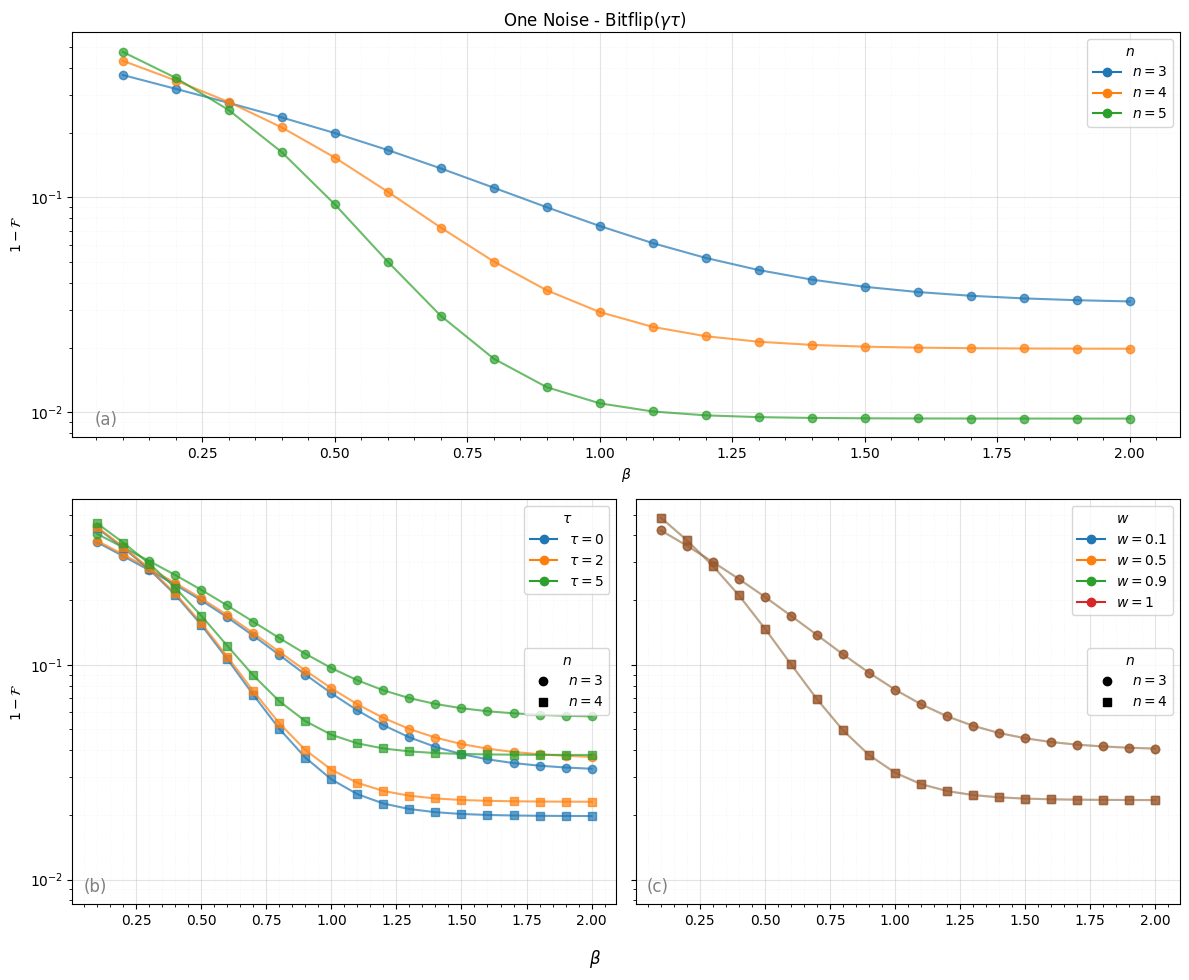

In [187]:
panel_fig, panel_axs = plt.subplot_mosaic(
    [["fig1a","fig1a"],["fig1b","fig1c"]],
    figsize=(12, 10),
    sharey=True, sharex=False,
    layout="tight"
)

plot_fidelity_variations(
    series1a,
    experiments_dir1,
    labelname="n",
    ax=panel_axs["fig1a"],
    title="(a)",
    alpha=0.7,
    ylabel=r"$1-\cal{F}$",
    xlabel=r"$\beta$"
)

plot_fidelity_variations(
    series1b,
    experiments_dir1,
    labelname=("n", r"\tau"),
    ax=panel_axs["fig1b"],
    title="(b)",
    alpha=0.7,
    ylabel=r"$1-\cal{F}$",
    xlabel=None
)

plot_fidelity_variations(
    series1c,
    experiments_dir1,
    labelname=("n", "w"),
    ax=panel_axs["fig1c"],
    title="(c)",
    alpha=0.2,
    ylabel=None,
    xlabel=None
)

panel_fig.suptitle(r"One Noise - Bitflip($\gamma\tau$)", y=0.97)
panel_fig.supxlabel(r"$\beta$", y=0.01)
panel_fig.savefig(ROOT_DIR / "visualization" / "panel1.png", bbox_inches="tight")
panel_fig.savefig(ROOT_DIR / "visualization" / "panel1.pdf", bbox_inches="tight", dpi=300)

## Fig.2
Here we split the possible noises in two

In [188]:
experiments_dir2 = ROOT_DIR / "experiments/fig2"
df2 = read_summary(experiments_dir2)

Adding column povm_weakness to dataframe...


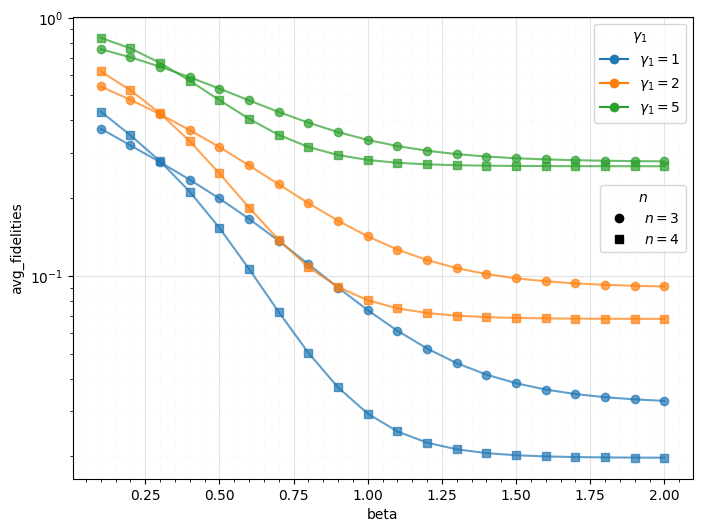

In [189]:
exp_name = "a_gamma1"
exp_variable = ["n_qubits", "noise_1_gamma"]

filtered_df = df2[df2["name"].str.startswith(exp_name)]
series2a1 = filtered_df.groupby(exp_variable)

fig2a1, ax2a1 = plot_fidelity_variations(series2a1, x_col="beta", y_col="avg_fidelities", plot_infidelity=True, labelname=("n", r"\gamma_1"), 
                         alpha=0.7,
                         experiments_dir=experiments_dir2,
                         savepath=experiments_dir2 / "fig2a1.png")

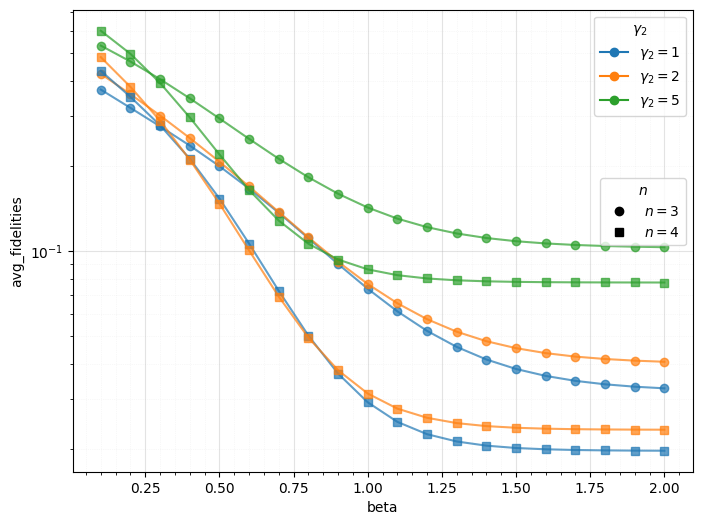

In [190]:
exp_name = "a_gamma2"
exp_variable = ["n_qubits", "noise_2_gamma"]

filtered_df = df2[df2["name"].str.startswith(exp_name)]
series2a2 = filtered_df.groupby(exp_variable)

fig2a2, ax2a2 = plot_fidelity_variations(series2a2, x_col="beta", y_col="avg_fidelities", plot_infidelity=True, labelname=("n", r"\gamma_2"), 
                         alpha=0.7,
                         experiments_dir=experiments_dir2,
                         savepath=experiments_dir2 / "fig2a2.png")

### Fig.1b
Here we show the effect of increasing the time of the first informative collision

0.023436795207231964


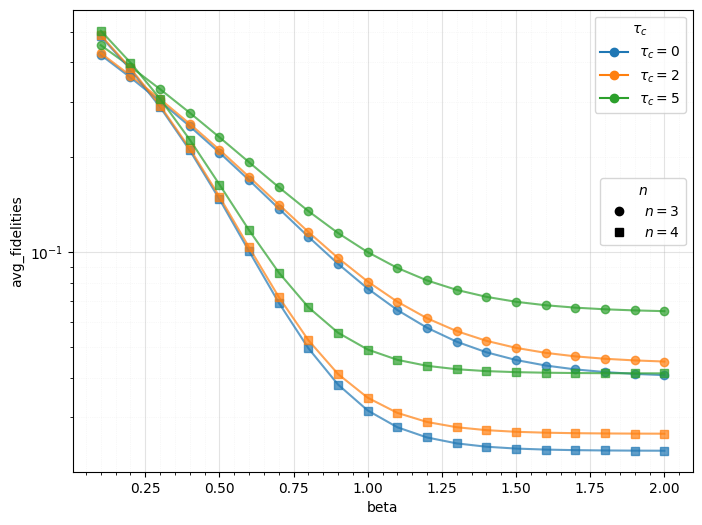

In [191]:
exp_name = "b_"
exp_variable = ["n_qubits", "coll_time"]

filtered_df = df2[df2["name"].str.startswith(exp_name)]
filtered_df = filtered_df[filtered_df["coll_time"].isin([0.0, 2.0, 5.0])]
series2b = filtered_df.groupby(exp_variable)

fig2b, ax2b = plot_fidelity_variations(series2b, x_col="beta", y_col="avg_fidelities", plot_infidelity=True, labelname=("n", r"\tau_c"), 
                                       alpha=0.7,
                                       experiments_dir=experiments_dir2,
                                       savepath=experiments_dir2 / "fig2b.png")
print(min(1 - filtered_df.avg_fidelity))

### Fig.1c
Here we show the effect of increasing the weight of the collapse, where in our weak measurements we mix the identity with the POVM as $\Pi_\text{weak}=w I + (1-w) \Pi$

0.023444722534927243


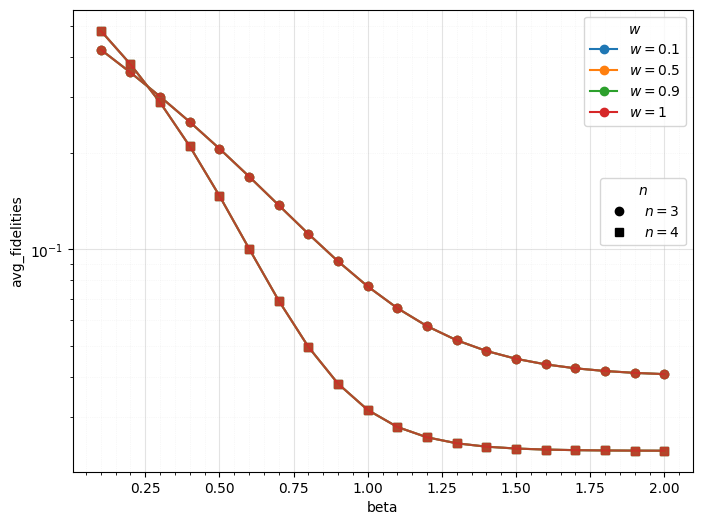

In [192]:
exp_name = "c_"
exp_variable = ["n_qubits", "povm_weakness"]

filtered_df = df2[df2["name"].str.startswith(exp_name)]
series2c = filtered_df.groupby(exp_variable)

fig2c, ax2c = plot_fidelity_variations(series2c, x_col="beta", y_col="avg_fidelities", plot_infidelity=True, labelname=("n", "w"), 
                                       alpha=0.7,
                                       experiments_dir=experiments_dir2,
                                       savepath=experiments_dir2 / "fig2c.png")

print(min(1 - filtered_df.avg_fidelity))

### Mosaic

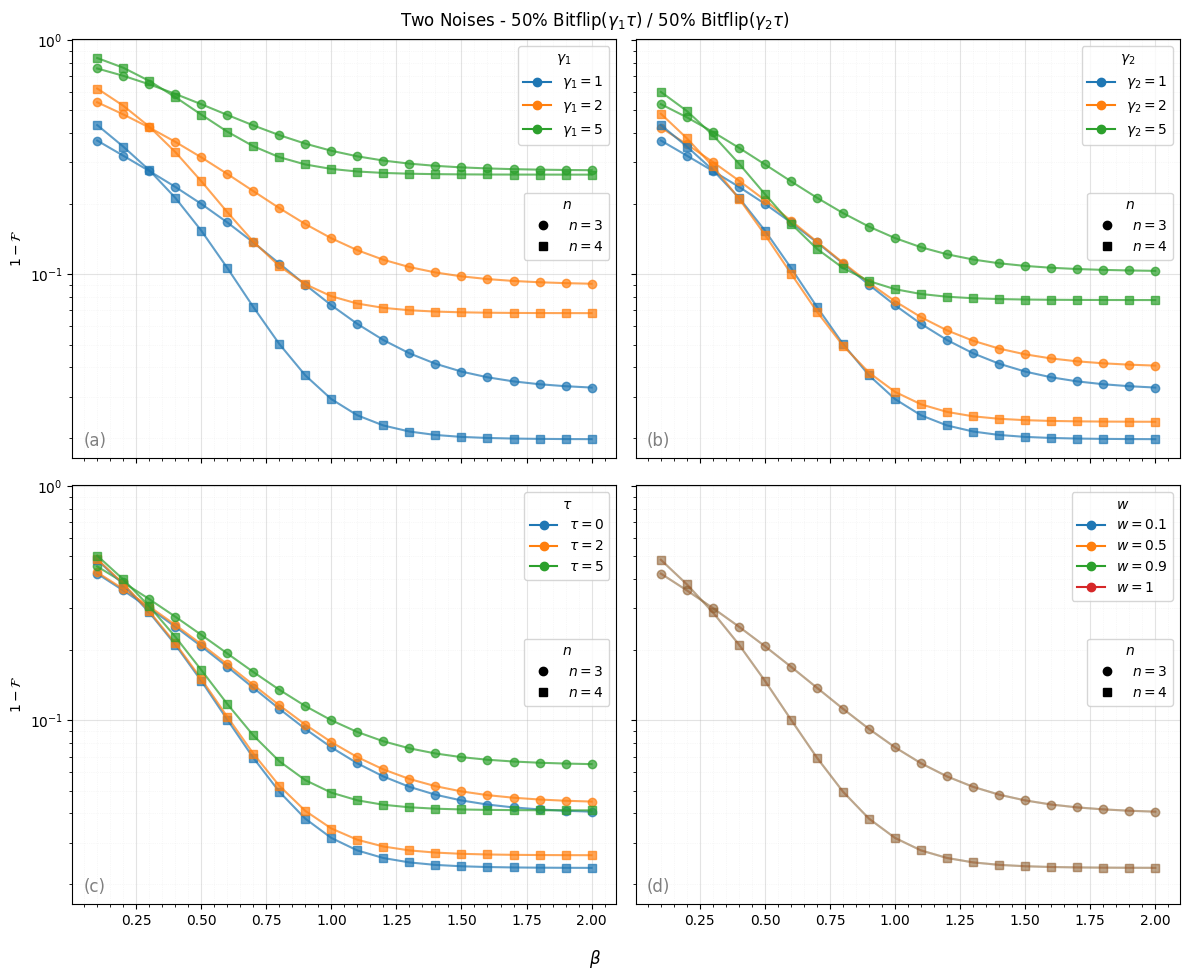

In [193]:
panel_fig, panel_axs = plt.subplot_mosaic(
    [["fig2a1","fig2a2"],["fig2b","fig2c"]],
    figsize=(12, 10),
    sharey=True, sharex=True,
    layout="tight"
)

plot_fidelity_variations(
    series2a1,
    experiments_dir2,
    labelname=("n", r"\gamma_1"),
    ax=panel_axs["fig2a1"],
    title="(a)",
    alpha=0.7,
    ylabel=r"$1-\cal{F}$",
    xlabel=None
)

plot_fidelity_variations(
    series2a2,
    experiments_dir2,
    labelname=("n", r"\gamma_2"),
    ax=panel_axs["fig2a2"],
    title="(b)",
    alpha=0.7,
    ylabel=None,
    xlabel=None
)

plot_fidelity_variations(
    series2b,
    experiments_dir2,
    labelname=("n", r"\tau"),
    ax=panel_axs["fig2b"],
    title="(c)",
    alpha=0.7,
    ylabel=r"$1-\cal{F}$",
    xlabel=None
)

plot_fidelity_variations(
    series2c,
    experiments_dir2,
    labelname=("n", "w"),
    ax=panel_axs["fig2c"],
    title="(d)",
    alpha=0.2,
    ylabel=None, 
    xlabel=None
)

panel_fig.suptitle(r"Two Noises - 50% Bitflip($\gamma_1\tau$) / 50% Bitflip($\gamma_2\tau$)", y=0.97)
panel_fig.supxlabel(r"$\beta$", y=0.01)
panel_fig.savefig(ROOT_DIR / "visualization" / "panel2.png", bbox_inches="tight")
panel_fig.savefig(ROOT_DIR / "visualization" / "panel2.pdf", bbox_inches="tight", dpi=300)

In [194]:
experiments_dir3 = ROOT_DIR / "experiments/fig3"
df3 = read_summary(experiments_dir3)

Adding column povm_weakness to dataframe...


0.0007568396357772178


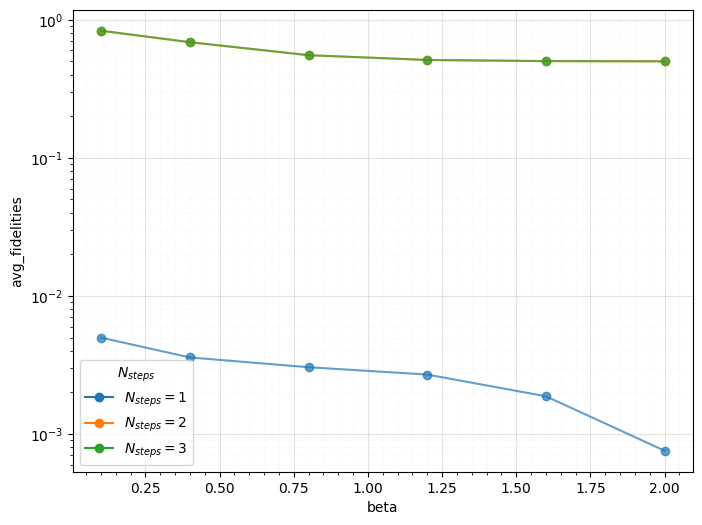

In [ ]:
exp_name = "steps_"
exp_variable = "n_timesteps"

filtered_df = df3[df3["name"].str.startswith(exp_name)]
series3a1 = filtered_df.groupby(exp_variable)

fig3a1, ax3a1 = plot_fidelity_variations(series3a1, x_col="beta", y_col="avg_fidelities", plot_infidelity=True, labelname="N_{steps}", 
                         alpha=0.7,
                         experiments_dir=experiments_dir3,
                        #  savepath=experiments_dir3 / "fig3a1.png"
                         )
print(min(1 - filtered_df.avg_fidelity))

In [200]:
folder = filtered_df.name.values[0]
supermaps = experiments_dir3 / folder / "data" / "superoperators.jld2"

folder

'steps_smallnoise_n3_b01_n_timesteps1'

In [197]:
experiments_dir4 = ROOT_DIR / "experiments/fig4"
df4 = read_summary(experiments_dir4)

exp_name = "steps_smallnoise_"
exp_variable = "n_timesteps"

filtered_df = df4[df4["name"].str.startswith(exp_name)]
series4a1 = filtered_df.groupby(exp_variable)

fig4a1, ax4a1 = plot_fidelity_variations(series4a1, x_col="beta", y_col="avg_fidelities", plot_infidelity=True, labelname="N_{steps}", 
                         alpha=0.7,
                         experiments_dir=experiments_dir4,
                        #  savepath=experiments_dir4 / "fig4a1.png"
                         )

FileNotFoundError: [Errno 2] No such file or directory: '../experiments/fig4/iterations_summary.csv'